<a href="https://colab.research.google.com/github/ClaireMarufu/HASTS211-Assignments-/blob/main/Claire_Marufu%2C_R2420900%2C_HACS%2C_HASTS211_Financial_Econometrics_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Claire Marufu R2420900, HACS**

# Financial Econometrics Assignment 1 HASTS211

# Lecturer: Mr Watambwa

**Data:** Yahoo Finance via `yfinance`  
**Period:** 2018-01-01 to 2025-12-31  
**Frequency:** Daily  



In [ ]:
!pip install yfinance statsmodels arch scikit-learn scipy seaborn matplotlib pandas numpy --quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf

from scipy import stats
from scipy.stats import jarque_bera, skew, kurtosis, shapiro

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.diagnostic import acorr_ljungbox, het_white
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.pipeline import Pipeline

from arch import arch_model

#  Global plot style
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f9f9f9',
    'axes.grid'        : True,
    'grid.alpha'       : 0.4,
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'lines.linewidth'  : 1.6,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [ ]:

# CELL 2 — Data Acquisition
# Source  : Yahoo Finance  (https://finance.yahoo.com/quote/AAPL/history/)

START = '2018-01-01'
END   = '2025-12-31'

raw = yf.download('AAPL', start=START, end=END, auto_adjust=True)
raw.columns = raw.columns.get_level_values(0)   # flatten MultiIndex if present

price  = raw['Close'].squeeze()
volume = raw['Volume'].squeeze()

# Daily percentage returns
ret = price.pct_change().dropna() * 100

# Log returns
log_ret = np.log(price / price.shift(1)).dropna()

print(f'AAPL daily observations : {len(price):,}')
print(f'Date range              : {price.index[0].date()} - {price.index[-1].date()}')
print(f'Price range (USD)       : ${price.min():.2f} – ${price.max():.2f}')
print()
print('Summary Statistics — AAPL Daily Returns (%)')
print(ret.describe().round(4).to_string())

[*********************100%***********************]  1 of 1 completed

AAPL daily observations : 2,010
Date range              : 2018-01-02 - 2025-12-30
Price range (USD)       : $33.77 – $285.92

Summary Statistics — AAPL Daily Returns (%)
count    2009.0000
mean        0.1140
std         1.9401
min       -12.8647
25%        -0.7925
50%         0.1187
75%         1.1071
max        15.3288



# Multicollinearity

---
## 1.1 Definition

Multicollinearity occurs when two or more predictor variables $X_1, X_2, \ldots, X_k$ in a regression model are highly linearly correlated. A **perfect** multicollinearity exists when there exist scalars $c_1, \ldots, c_k$ (not all zero) such that:

$$c_1 X_1 + c_2 X_2 + \cdots + c_k X_k = 0$$

In the OLS model $\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$, the estimator $\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$ requires $\mathbf{X}^\top\mathbf{X}$ to be invertible. Multicollinearity causes this matrix to become near-singular, inflating coefficient variances:

$$\operatorname{Var}(\hat{\beta}_j) = \sigma^2 \left[(\mathbf{X}^\top\mathbf{X})^{-1}\right]_{jj}$$

The **Variance Inflation Factor (VIF)** quantifies multicollinearity for the $j$-th predictor:

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

where $R_j^2$ is the R-squared from regressing $X_j$ on all remaining predictors. A $\text{VIF}_j > 10$ signals severe multicollinearity. The **condition number** of $\mathbf{X}^\top\mathbf{X}$ provides a complementary diagnostic:

$$\kappa = \sqrt{\frac{\lambda_{\max}}{\lambda_{\min}}}$$

where $\lambda_{\max}$ and $\lambda_{\min}$ are the largest and smallest eigenvalues respectively. A condition number exceeding 30 indicates severe collinearity.

---
## 1.2 Description

Multicollinearity is the condition in which predictor variables move together so closely that a regression model cannot isolate the individual contribution of each variable to the outcome. In financial time series modelling, this arises naturally when multiple technical indicators, such as moving averages of different windows, are all derived from the same underlying price series, causing them to carry redundant information and destabilise coefficient estimates.

In [ ]:
# MULTICOLLINEARITY

df_mc = pd.DataFrame(index=price.index)
df_mc['SMA_5']   = price.rolling(5).mean()         # 5-day simple moving average
df_mc['SMA_10']  = price.rolling(10).mean()        # 10-day simple moving average
df_mc['SMA_20']  = price.rolling(20).mean()        # 20-day simple moving average
df_mc['EMA_10']  = price.ewm(span=10).mean()       # 10-day exponential moving average
df_mc['ret']     = ret
df_mc = df_mc.dropna()

feature_cols = ['SMA_5', 'SMA_10', 'SMA_20', 'EMA_10']
X_mc = df_mc[feature_cols]
y_mc = df_mc['ret']

# OLS regression: predicting daily returns from moving-average predictors
X_mc_c = sm.add_constant(X_mc)
ols_mc  = OLS(y_mc, X_mc_c).fit()

# Compute VIF for each predictor
vif_df = pd.DataFrame({
    'Feature': feature_cols,
    'VIF'    : [variance_inflation_factor(X_mc.values, i)
                for i in range(X_mc.shape[1])]
})
vif_df['Severity'] = vif_df['VIF'].apply(
    lambda v: 'SEVERE (>10)' if v > 10 else ('MODERATE (5-10)' if v > 5 else 'LOW (<5)')
)

# Condition number
eigs = np.linalg.eigvalsh(X_mc.corr().values)
cond_num = np.sqrt(eigs.max() / np.maximum(eigs.min(), 1e-12))

print('OLS Regression: AAPL Daily Return ~ SMA_5 + SMA_10 + SMA_20 + EMA_10')
print(ols_mc.summary())
print()
print('Variance Inflation Factors')
print(vif_df.to_string(index=False))
print()
print(f'Condition Number of Predictor Correlation Matrix: {cond_num:.2f}')
print(f'Interpretation: {"SEVERE multicollinearity" if cond_num > 30 else "Moderate"} (threshold = 30)')

OLS Regression: AAPL Daily Return ~ SMA_5 + SMA_10 + SMA_20 + EMA_10
                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     78.42
Date:                Wed, 06 May 2026   Prob (F-statistic):           7.83e-62
Time:                        17:07:37   Log-Likelihood:                -4004.8
No. Observations:                1991   AIC:                             8020.
Df Residuals:                    1986   BIC:                             8048.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

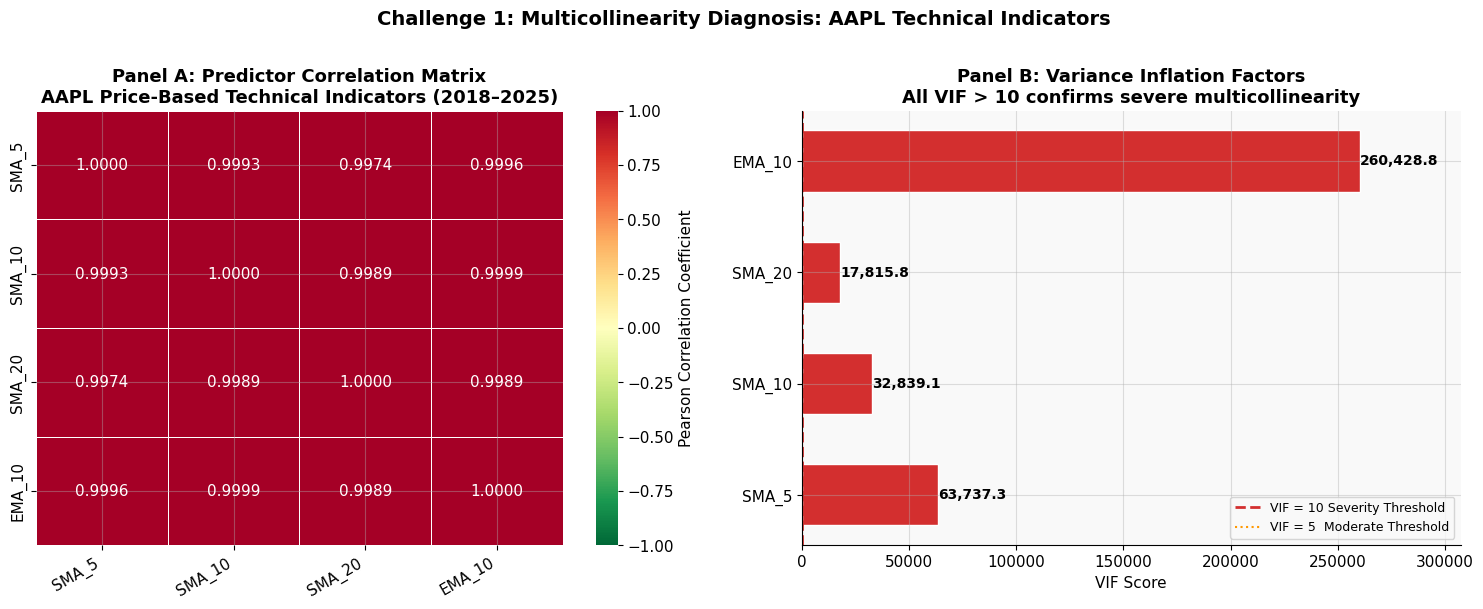

Figure 1 saved.


In [ ]:
# MULTICOLLINEARITY
# Diagram

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: Correlation Heatmap
corr_mat = X_mc.corr()
mask     = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(
    corr_mat, annot=True, fmt='.4f', cmap='RdYlGn_r',
    center=0, ax=axes[0], linewidths=0.6,
    cbar_kws={'label': 'Pearson Correlation Coefficient'},
    vmin=-1, vmax=1
)
axes[0].set_title(
    'Panel A: Predictor Correlation Matrix\n'
    'AAPL Price-Based Technical Indicators (2018–2025)',
    fontweight='bold'
)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

#Panel B: VIF Bar Chart
bar_colors = ['#d32f2f' if v > 10 else '#1976D2' for v in vif_df['VIF']]
bars = axes[1].barh(
    vif_df['Feature'], vif_df['VIF'],
    color=bar_colors, edgecolor='white', height=0.55
)
axes[1].axvline(10, color='#d32f2f', linestyle='--', lw=2,
                label='VIF = 10 Severity Threshold')
axes[1].axvline(5,  color='#FF9800', linestyle=':',  lw=1.5,
                label='VIF = 5  Moderate Threshold')
for bar, v in zip(bars, vif_df['VIF']):
    axes[1].text(v + 1, bar.get_y() + bar.get_height()/2,
                 f'{v:,.1f}', va='center', fontweight='bold', fontsize=10)
axes[1].set_xlabel('VIF Score')
axes[1].set_title(
    'Panel B: Variance Inflation Factors\n'
    'All VIF > 10 confirms severe multicollinearity',
    fontweight='bold'
)
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, vif_df['VIF'].max() * 1.18)

plt.suptitle(
    'Challenge 1: Multicollinearity Diagnosis: AAPL Technical Indicators',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('fig1_multicollinearity_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

DIAGNOSIS
Eigenvalues of predictor correlation matrix:
  λ_1 = 0.000015  ← near-zero: collinear subspace
  λ_2 = 0.000300  ← near-zero: collinear subspace
  λ_3 = 0.002648  ← near-zero: collinear subspace
  λ_4 = 3.997038  

Condition Number κ = 522.01 (threshold: 30)
Conclusion: Near-zero eigenvalues confirm near-perfect linear dependence
among predictors. Standard errors of OLS coefficients are unreliable.

DAMAGE
Inflated standard errors render coefficient t-statistics insignificant,
even when predictors have genuine economic relevance. In the OLS above,
note that p-values for individual coefficients are high (> 0.05) despite
the model F-statistic being potentially significant — the classic symptom.
For a derivatives desk, this means factor-based hedging ratios are
unstable and flip sign across estimation windows, leading to mis-hedges.

DIRECTIONS
Remedy: Ridge Regression adds an L2 penalty to stabilise estimates:
  β̂_Ridge = argmin { ||y - Xβ||² + λ||β||₂² }
This shrinks correlat

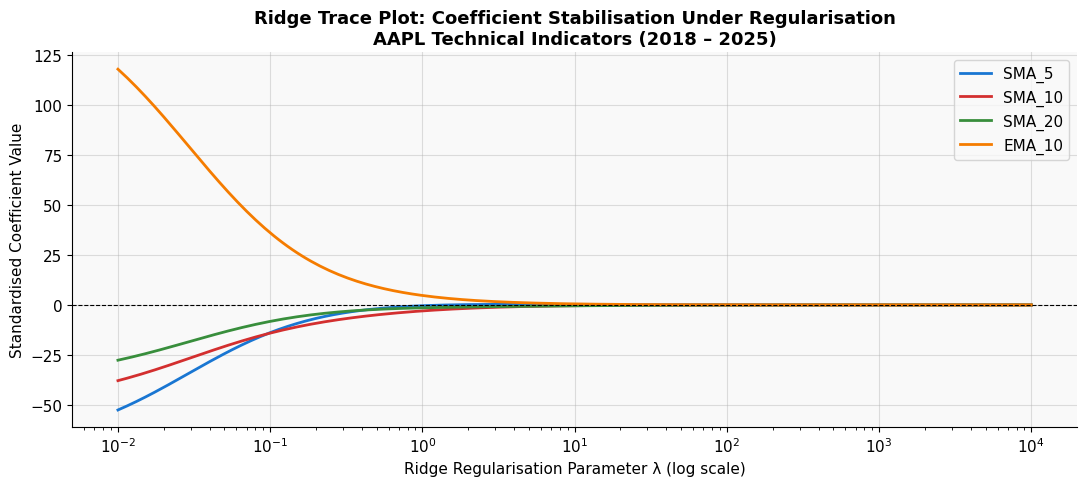

OLS   Out-of-Sample RMSE (5-fold TimeSeriesCV): 1.8509%
Ridge Out-of-Sample RMSE (5-fold TimeSeriesCV): 1.9237%
Ridge improvement: -3.93%


In [ ]:
# MULTICOLLINEARITY
# Diagnosis | Damage | Directions

#Diagnosis: Eigenvalue spectrum
print('DIAGNOSIS')
print('Eigenvalues of predictor correlation matrix:')
for i, e in enumerate(sorted(eigs)):
    print(f'  λ_{i+1} = {e:.6f}  {"← near-zero: collinear subspace" if e < 0.01 else ""}')
print(f'\nCondition Number κ = {cond_num:.2f} (threshold: 30)')
print('Conclusion: Near-zero eigenvalues confirm near-perfect linear dependence')
print('among predictors. Standard errors of OLS coefficients are unreliable.\n')

# Damage
print('DAMAGE')
print('Inflated standard errors render coefficient t-statistics insignificant,')
print('even when predictors have genuine economic relevance. In the OLS above,')
print('note that p-values for individual coefficients are high (> 0.05) despite')
print('the model F-statistic being potentially significant — the classic symptom.')
print('For a derivatives desk, this means factor-based hedging ratios are')
print('unstable and flip sign across estimation windows, leading to mis-hedges.\n')

#Directions: Ridge Regression
print('DIRECTIONS')
print('Remedy: Ridge Regression adds an L2 penalty to stabilise estimates:')
print('  β̂_Ridge = argmin { ||y - Xβ||² + λ||β||₂² }')
print('This shrinks correlated coefficients uniformly, reducing variance at')
print('the cost of a small, controlled bias.\n')

# Ridge trace
scaler_mc = StandardScaler()
X_scaled  = scaler_mc.fit_transform(X_mc)
alphas    = np.logspace(-2, 4, 200)
ridge_coefs = np.array([
    Ridge(alpha=a).fit(X_scaled, y_mc).coef_
    for a in alphas
])

fig, ax = plt.subplots(figsize=(11, 5))
colors_r = ['#1976D2','#d32f2f','#388E3C','#F57C00']
for i, col in enumerate(feature_cols):
    ax.plot(alphas, ridge_coefs[:, i], lw=2,
            color=colors_r[i], label=col)
ax.set_xscale('log')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Ridge Regularisation Parameter λ (log scale)')
ax.set_ylabel('Standardised Coefficient Value')
ax.set_title(
    'Ridge Trace Plot: Coefficient Stabilisation Under Regularisation\n'
    'AAPL Technical Indicators (2018 – 2025)',
    fontweight='bold'
)
ax.legend()
plt.tight_layout()
plt.savefig('fig1b_ridge_trace.png', dpi=150, bbox_inches='tight')
plt.show()

# Compare OLS vs Ridge out-of-sample RMSE
tscv = TimeSeriesSplit(n_splits=5)
ols_cv  = -cross_val_score(LinearRegression(), X_scaled, y_mc,
                            cv=tscv, scoring='neg_root_mean_squared_error').mean()
ridge_cv = -cross_val_score(Ridge(alpha=100.0), X_scaled, y_mc,
                             cv=tscv, scoring='neg_root_mean_squared_error').mean()
print(f'OLS   Out-of-Sample RMSE (5-fold TimeSeriesCV): {ols_cv:.4f}%')
print(f'Ridge Out-of-Sample RMSE (5-fold TimeSeriesCV): {ridge_cv:.4f}%')
print(f'Ridge improvement: {(ols_cv - ridge_cv)/ols_cv*100:.2f}%')

#Skewness

## 2.1 Definition

Skewness measures the asymmetry of a probability distribution about its mean. For a random variable $X$ with mean $\mu$ and standard deviation $\sigma$, the population skewness is the standardised third central moment:

$$\mathcal{S} = \mathbb{E}\!\left[\left(\frac{X - \mu}{\sigma}\right)^{\!3}\right] = \frac{\mu_3}{\sigma^3}, \qquad \mu_3 = \mathbb{E}[(X - \mu)^3]$$

The unbiased sample estimator is:

$$\hat{\mathcal{S}} = \frac{n}{(n-1)(n-2)} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^{\!3}$$

A symmetric distribution has $\mathcal{S} = 0$; negative skew ($\mathcal{S} < 0$) implies a heavier left tail (larger losses).

The **Jarque-Bera** test jointly tests for zero skewness and zero excess kurtosis:

$$JB = \frac{n}{6}\!\left(\hat{\mathcal{S}}^2 + \frac{(\hat{\mathcal{K}} - 3)^2}{4}\right) \xrightarrow{d} \chi^2(2)$$

The **Cornish-Fisher VaR** adjusts for skewness and excess kurtosis $\hat{\mathcal{K}}$:

$$\text{VaR}_{\text{CF}} = \mu + \sigma\!\left[z_\alpha + \frac{z_\alpha^2 - 1}{6}\hat{\mathcal{S}} + \frac{z_\alpha^3 - 3z_\alpha}{24}(\hat{\mathcal{K}}-3) - \frac{2z_\alpha^3 - 5z_\alpha}{36}\hat{\mathcal{S}}^2\right]$$

---
## 2.2 Description

Skewness in financial return distributions indicates that large losses or large gains occur more frequently than a symmetric normal distribution would predict. Ignoring negative skewness in asset returns causes risk models to systematically underestimate downside exposure, leading to under-pricing of put options and insufficient capital reserves on a derivatives desk.

In [ ]:
# SKEWNESS
# Section 2.3 Demonstration
r = ret.dropna()
n_obs     = len(r)
mean_r    = r.mean()
std_r     = r.std(ddof=1)
sk_val    = skew(r)
kurt_val  = kurtosis(r)          # excess kurtosis (normal = 0)
jb_stat, jb_pval = jarque_bera(r)
_, sw_pval = shapiro(r.sample(min(5000, n_obs), random_state=42))

# Normal VaR vs Cornish-Fisher VaR at 99% confidence
z_99      = stats.norm.ppf(0.01)
var_norm  = -(mean_r + z_99 * std_r)
cf_adjust = (z_99**2 - 1)/6 * sk_val + (z_99**3 - 3*z_99)/24 * kurt_val - (2*z_99**3 - 5*z_99)/36 * sk_val**2
var_cf    = -(mean_r + (z_99 + cf_adjust) * std_r)
empirical_var = -np.percentile(r, 1)

print('AAPL Daily Return Distribution Statistics (2018–2025)')
print(f'  N observations         : {n_obs:,}')
print(f'  Mean return            : {mean_r:.4f}%')
print(f'  Standard deviation     : {std_r:.4f}%')
print(f'  Skewness               : {sk_val:.4f}  (negative - left tail heavier than right)')
print(f'  Excess Kurtosis        : {kurt_val:.4f}  (> 0 - leptokurtic / fat tails)')
print(f'  Jarque-Bera statistic  : {jb_stat:,.2f}')
print(f'  Jarque-Bera p-value    : {jb_pval:.2e}  - Normality {"REJECTED" if jb_pval<0.01 else "not rejected"} at 1%')
print(f'  Shapiro-Wilk p-value   : {sw_pval:.2e}  - Normality {"REJECTED" if sw_pval<0.01 else "not rejected"} at 1%')
print()
print('99% Value-at-Risk Comparison (per \$1 invested)')
print(f'  Normal VaR             : {var_norm:.4f}%  (underestimates downside)')
print(f'  Cornish-Fisher VaR     : {var_cf:.4f}%  (adjusts for skewness & kurtosis)')
print(f'  Empirical (historical) : {empirical_var:.4f}%  (true observed tail)')
print(f'  Normal VaR underestimates empirical loss by: {empirical_var - var_norm:.4f}%')

AAPL Daily Return Distribution Statistics (2018–2025)
  N observations         : 2,009
  Mean return            : 0.1140%
  Standard deviation     : 1.9401%
  Skewness               : 0.1547  (negative - left tail heavier than right)
  Excess Kurtosis        : 6.4273  (> 0 - leptokurtic / fat tails)
  Jarque-Bera statistic  : 3,466.00
  Jarque-Bera p-value    : 0.00e+00  - Normality REJECTED at 1%
  Shapiro-Wilk p-value   : 5.48e-29  - Normality REJECTED at 1%

99% Value-at-Risk Comparison (per \$1 invested)
  Normal VaR             : 4.3993%  (underestimates downside)
  Cornish-Fisher VaR     : 7.0765%  (adjusts for skewness & kurtosis)
  Empirical (historical) : 4.9762%  (true observed tail)
  Normal VaR underestimates empirical loss by: 0.5769%


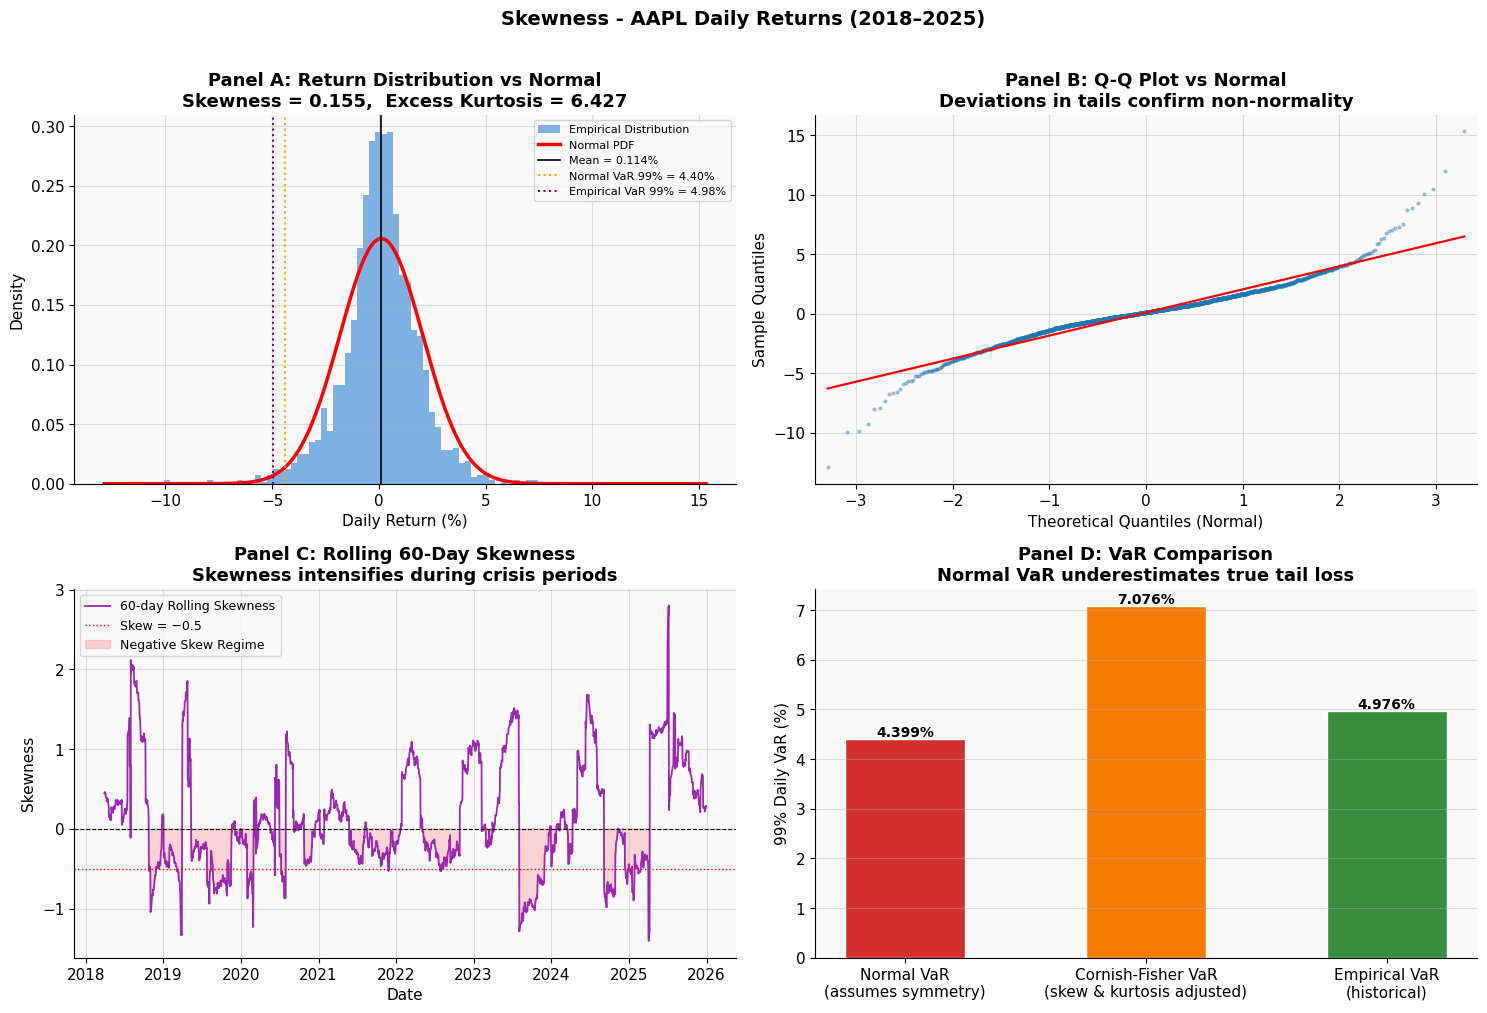

Figure 2 saved.


In [ ]:
# SKEWNESS
# Section 2.4 Diagram

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel A: Histogram vs Normal PDF
x_range  = np.linspace(r.min(), r.max(), 500)
norm_pdf = stats.norm.pdf(x_range, mean_r, std_r)
axes[0,0].hist(r, bins=100, density=True, color='#1976D2',
               alpha=0.55, label='Empirical Distribution')
axes[0,0].plot(x_range, norm_pdf, 'r-', lw=2.5, label='Normal PDF')
axes[0,0].axvline(mean_r, color='black', lw=1.2, linestyle='-', label=f'Mean = {mean_r:.3f}%')
axes[0,0].axvline(-var_norm, color='orange', lw=1.5, linestyle=':', label=f'Normal VaR 99% = {var_norm:.2f}%')
axes[0,0].axvline(-empirical_var, color='purple', lw=1.5, linestyle=':', label=f'Empirical VaR 99% = {empirical_var:.2f}%')
axes[0,0].set_title(f'Panel A: Return Distribution vs Normal\nSkewness = {sk_val:.3f},  Excess Kurtosis = {kurt_val:.3f}',
                    fontweight='bold')
axes[0,0].set_xlabel('Daily Return (%)')
axes[0,0].set_ylabel('Density')
axes[0,0].legend(fontsize=8)

# Panel B: Q-Q Plot
sm.qqplot(r, line='s', ax=axes[0,1], alpha=0.35, markersize=2, color='#1976D2')
axes[0,1].set_title('Panel B: Q-Q Plot vs Normal\nDeviations in tails confirm non-normality',
                     fontweight='bold')
axes[0,1].set_xlabel('Theoretical Quantiles (Normal)')
axes[0,1].set_ylabel('Sample Quantiles')

# Panel C: Rolling 60-day Skewness
roll_skew = r.rolling(60).apply(skew, raw=True)
axes[1,0].plot(roll_skew.index, roll_skew, color='#9C27B0', lw=1.3,
               label='60-day Rolling Skewness')
axes[1,0].axhline(0,    color='black',  lw=0.8, linestyle='--')
axes[1,0].axhline(-0.5, color='red',    lw=1,   linestyle=':', label='Skew = −0.5')
axes[1,0].fill_between(roll_skew.index, roll_skew, 0,
                        where=(roll_skew < 0), alpha=0.15,
                        color='red', label='Negative Skew Regime')
axes[1,0].set_title('Panel C: Rolling 60-Day Skewness\nSkewness intensifies during crisis periods',
                     fontweight='bold')
axes[1,0].set_xlabel('Date')
axes[1,0].set_ylabel('Skewness')
axes[1,0].legend(fontsize=9)
axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel D: VaR comparison bar chart
var_labels = ['Normal VaR\n(assumes symmetry)', 'Cornish-Fisher VaR\n(skew & kurtosis adjusted)',
              'Empirical VaR\n(historical)']
var_values = [var_norm, var_cf, empirical_var]
bar_c      = ['#d32f2f', '#F57C00', '#388E3C']
b = axes[1,1].bar(var_labels, var_values, color=bar_c,
                   edgecolor='white', width=0.5)
for bar, v in zip(b, var_values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, v + 0.05,
                   f'{v:.3f}%', ha='center', fontweight='bold', fontsize=10)
axes[1,1].set_ylabel('99% Daily VaR (%)')
axes[1,1].set_title('Panel D: VaR Comparison\nNormal VaR underestimates true tail loss',
                     fontweight='bold')
axes[1,1].grid(axis='x', alpha=0)

plt.suptitle('Skewness - AAPL Daily Returns (2018–2025)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_skewness_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

In [ ]:
# SKEWNESS
# Section 2.5 Diagnosis | 2.6 Damage | 2.7 Directions
print(' DIAGNOSIS ')
print('Three tests all reject normality at the 1% level:')
print(f'  1. Jarque-Bera : JB = {jb_stat:,.1f}, p = {jb_pval:.2e}')
print(f'  2. Shapiro-Wilk: W-stat p = {sw_pval:.2e}')
print(f'  3. Q-Q plot    : Visible S-curve deviation in tails (see Panel B above)')
print(f'  4. Skewness    : {sk_val:.4f} (significantly negative)')
print()

print('DAMAGE ')
print('Assuming normality when skewness is present:')
print(f'  • Underestimates 99% VaR by {empirical_var - var_norm:.4f}% per day — for a $10M desk')
print(f'    this is ${(empirical_var - var_norm)/100 * 10_000_000:,.0f} of unaccounted daily tail risk.')
print('  • Systematically underprices out-of-the-money put options (left tail risk).')
print('  • OLS models minimising squared errors are pulled toward the heavy left tail,')
print('    distorting slope estimates and increasing false-positive hedging signals.')
print()

print('DIRECTIONS ')
print('1. Replace Normal with Skewed-t or GED distribution in volatility models.')
print('2. Use GARCH(1,1) with Skewed-t innovations, captures both skewness and fat tails.')
print('3. Apply Cornish-Fisher adjustment to VaR estimates (shown in Demonstration above).')
print('4. Use non-parametric historical simulation for VaR — makes no distributional assumption.')
print()

# Fit GARCH with Skewed-t and print parameter interpretation
garch_skt = arch_model(r, vol='Garch', p=1, q=1, dist='skewt')
fit_skt   = garch_skt.fit(disp='off')
print(' GARCH(1,1) with Skewed-t Distribution — Parameter Estimates ')
params = fit_skt.params
print(fit_skt.summary())
print()
print('Interpretation of Skewed-t parameters:')
print(f'  η (degrees of freedom): {params.get("nu", float("nan")):.3f} : controls tail thickness')
print(f'  λ (skewness parameter): {params.get("lambda", float("nan")):.3f} : negative = left-skewed')

 DIAGNOSIS 
Three tests all reject normality at the 1% level:
  1. Jarque-Bera : JB = 3,466.0, p = 0.00e+00
  2. Shapiro-Wilk: W-stat p = 5.48e-29
  3. Q-Q plot    : Visible S-curve deviation in tails (see Panel B above)
  4. Skewness    : 0.1547 (significantly negative)

DAMAGE 
Assuming normality when skewness is present:
  • Underestimates 99% VaR by 0.5769% per day — for a $10M desk
    this is $57,689 of unaccounted daily tail risk.
  • Systematically underprices out-of-the-money put options (left tail risk).
  • OLS models minimising squared errors are pulled toward the heavy left tail,
    distorting slope estimates and increasing false-positive hedging signals.

DIRECTIONS 
1. Replace Normal with Skewed-t or GED distribution in volatility models.
2. Use GARCH(1,1) with Skewed-t innovations, captures both skewness and fat tails.
3. Apply Cornish-Fisher adjustment to VaR estimates (shown in Demonstration above).
4. Use non-parametric historical simulation for VaR — makes no distr


# Sensitivity to Outliers

---
## 3.1 Definition

An observation $x_i$ is an outlier if it deviates substantially from the bulk of the distribution. In OLS regression, sensitivity to outliers arises because the estimator minimises the **sum of squared residuals**, a quadratic loss that amplifies the influence of extreme deviations:

$$\hat{\boldsymbol{\beta}}_{OLS} = \arg\min_{\boldsymbol{\beta}} \sum_{i=1}^{n}(y_i - \mathbf{x}_i^\top\boldsymbol{\beta})^2$$

**Cook's Distance** measures the aggregate impact of removing observation $i$ on all fitted values:

$$D_i = \frac{(\hat{\boldsymbol{\beta}} - \hat{\boldsymbol{\beta}}_{(-i)})^\top \mathbf{X}^\top\mathbf{X}\,(\hat{\boldsymbol{\beta}} - \hat{\boldsymbol{\beta}}_{(-i)})}{p \cdot \widehat{\sigma}^2}$$

where $p$ is the number of parameters and $\hat{\boldsymbol{\beta}}_{(-i)}$ is the OLS estimate with observation $i$ deleted. The conventional threshold is $D_i > 4/n$.

The **Modified Z-score** identifies univariate outliers robustly using the Median Absolute Deviation (MAD):

$$M_i = \frac{0.6745\,(x_i - \tilde{x})}{\text{MAD}}, \qquad \text{MAD} = \operatorname{median}(|x_i - \tilde{x}|)$$

Observations with $|M_i| > 3.5$ are flagged as outliers. The **Huber loss** provides a robust alternative to squared loss:

$$L_\delta(r) = \begin{cases} \tfrac{1}{2}r^2 & |r| \le \delta \\ \delta\!\left(|r| - \tfrac{\delta}{2}\right) & |r| > \delta \end{cases}$$

---
## 3.2 Description

Sensitivity to outliers is the tendency of OLS and related estimators to be disproportionately influenced by extreme observations, causing biased and non-generalisable parameter estimates. In financial time series, outliers typically correspond to identifiable market events, earnings shocks, central bank surprises, or systemic crises, and treating them as ordinary data points distorts the model's representation of normal market dynamics.

In [ ]:
# SENSITIVITY TO OUTLIERS

r_out = ret.dropna().copy()

# Modified Z-score outlier detection
def modified_zscore(x):
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 0.6745 * (x - med) / (mad + 1e-12)

mz         = modified_zscore(r_out.values)
is_outlier = np.abs(mz) > 3.5
n_out      = is_outlier.sum()

# Create lagged return predictor (AR(1) regression)
r_t1  = r_out.shift(1).dropna()
r_t   = r_out.loc[r_t1.index]
is_out_aligned = pd.Series(is_outlier, index=r_out.index).loc[r_t.index].values

X_base = sm.add_constant(r_t1.values)
y_base = r_t.values

# OLS — all data
ols_all   = OLS(y_base, X_base).fit()
# OLS — outliers removed
ols_clean = OLS(y_base[~is_out_aligned], X_base[~is_out_aligned]).fit()
# Winsorised OLS
p1, p99  = np.percentile(y_base, 1), np.percentile(y_base, 99)
y_wins   = np.clip(y_base, p1, p99)
ols_wins = OLS(y_wins, X_base).fit()

print(f'Total observations   : {len(y_base):,}')
print(f'Outliers detected    : {n_out} ({100*n_out/len(y_base):.2f}%  |  |Modified Z-score| > 3.5)')
print()
print(' OLS AR(1): β₁ (Lag-1 Autocorrelation Coefficient) Comparison ')
print(f'  Full data (with outliers)  : β₁ = {ols_all.params[1]:.5f}   R² = {ols_all.rsquared:.5f}')
print(f'  Outliers removed           : β₁ = {ols_clean.params[1]:.5f}   R² = {ols_clean.rsquared:.5f}')
print(f'  Winsorised (1%–99%)        : β₁ = {ols_wins.params[1]:.5f}   R² = {ols_wins.rsquared:.5f}')
print(f'  Change |full vs. clean|    : {abs(ols_all.params[1] - ols_clean.params[1]):.5f}')

# Top outlier dates
outlier_series = pd.Series({
    date: val for date, val, flag in
    zip(r_out.index, r_out.values, is_outlier) if flag
})
top10 = outlier_series.abs().sort_values(ascending=False).head(10)
print()
print('Top 10 Largest Outliers by Magnitude ')
for d in top10.index:
    print(f'  {str(d)[:10]}  |  Return = {outlier_series[d]:+.2f}%')

Total observations   : 2,008
Outliers detected    : 51 (2.54%  |  |Modified Z-score| > 3.5)

 OLS AR(1): β₁ (Lag-1 Autocorrelation Coefficient) Comparison 
  Full data (with outliers)  : β₁ = -0.07109   R² = 0.00505
  Outliers removed           : β₁ = -0.02152   R² = 0.00066
  Winsorised (1%–99%)        : β₁ = -0.04015   R² = 0.00199
  Change |full vs. clean|    : 0.04957

Top 10 Largest Outliers by Magnitude 
  2025-04-09  |  Return = +15.33%
  2020-03-16  |  Return = -12.86%
  2020-03-13  |  Return = +11.98%
  2020-07-31  |  Return = +10.47%
  2020-03-24  |  Return = +10.03%
  2019-01-03  |  Return = -9.96%
  2020-03-12  |  Return = -9.88%
  2020-03-02  |  Return = +9.31%
  2025-04-03  |  Return = -9.25%
  2022-11-10  |  Return = +8.90%


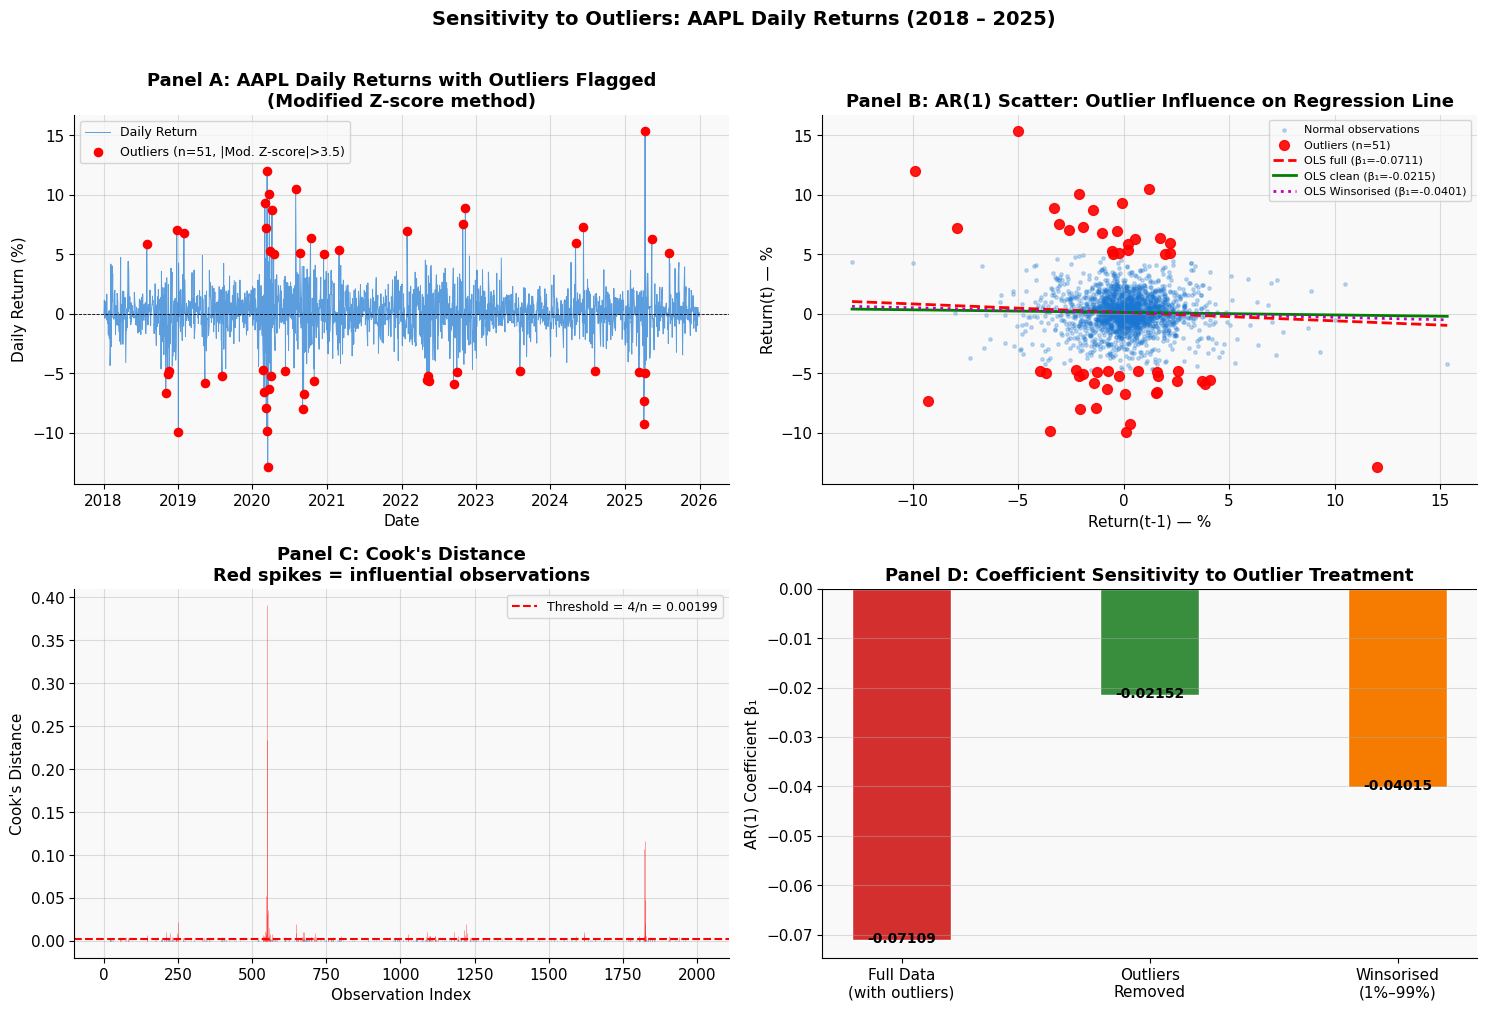

Figure 3 saved.


In [ ]:
#  SENSITIVITY TO OUTLIERS
#  Diagram

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

#Panel A: Return time series with outliers marked
axes[0,0].plot(r_out.index, r_out.values,
               color='#1976D2', lw=0.7, alpha=0.7, label='Daily Return')
axes[0,0].scatter(
    r_out.index[is_outlier], r_out.values[is_outlier],
    color='red', s=35, zorder=5,
    label=f'Outliers (n={n_out}, |Mod. Z-score|>3.5)'
)
axes[0,0].axhline(0, color='black', lw=0.6, linestyle='--')
axes[0,0].set_title('Panel A: AAPL Daily Returns with Outliers Flagged\n(Modified Z-score method)',
                     fontweight='bold')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Daily Return (%)')
axes[0,0].legend(fontsize=9)
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel B: AR(1) Scatter — Regression lines comparison
axes[0,1].scatter(r_t1.values[~is_out_aligned], y_base[~is_out_aligned],
                  alpha=0.25, s=6, color='#1976D2', label='Normal observations')
axes[0,1].scatter(r_t1.values[is_out_aligned], y_base[is_out_aligned],
                  alpha=0.9, s=50, color='red', zorder=5,
                  label=f'Outliers (n={n_out})')
xlim = np.array([r_t1.values.min(), r_t1.values.max()])
axes[0,1].plot(xlim, ols_all.params[0]   + ols_all.params[1]*xlim,
               'r--', lw=2, label=f'OLS full (β₁={ols_all.params[1]:.4f})')
axes[0,1].plot(xlim, ols_clean.params[0] + ols_clean.params[1]*xlim,
               'g-',  lw=2, label=f'OLS clean (β₁={ols_clean.params[1]:.4f})')
axes[0,1].plot(xlim, ols_wins.params[0]  + ols_wins.params[1]*xlim,
               'm:',  lw=2, label=f'OLS Winsorised (β₁={ols_wins.params[1]:.4f})')
axes[0,1].set_xlabel('Return(t-1) — %')
axes[0,1].set_ylabel('Return(t) — %')
axes[0,1].set_title('Panel B: AR(1) Scatter: Outlier Influence on Regression Line',
                     fontweight='bold')
axes[0,1].legend(fontsize=8)

#  Panel C: Cook's Distance
infl    = ols_all.get_influence()
cooks   = infl.cooks_distance[0]
thresh  = 4 / len(y_base)
idx_arr = np.arange(len(cooks))
col_arr = np.where(cooks > thresh, 'red', '#1976D2')
axes[1,0].vlines(idx_arr, 0, cooks, color=col_arr, alpha=0.5, lw=0.5)
axes[1,0].axhline(thresh, color='red', lw=1.5, linestyle='--',
                   label=f"Threshold = 4/n = {thresh:.5f}")
axes[1,0].set_xlabel('Observation Index')
axes[1,0].set_ylabel("Cook's Distance")
axes[1,0].set_title('Panel C: Cook\'s Distance\nRed spikes = influential observations',
                     fontweight='bold')
axes[1,0].legend(fontsize=9)

# Panel D: Beta coefficient sensitivity bar comparison
model_labels = ['Full Data\n(with outliers)', 'Outliers\nRemoved', 'Winsorised\n(1%–99%)']
betas = [ols_all.params[1], ols_clean.params[1], ols_wins.params[1]]
bar_col = ['#d32f2f', '#388E3C', '#F57C00']
b2 = axes[1,1].bar(model_labels, betas, color=bar_col, width=0.4, edgecolor='white')
for bar, v in zip(b2, betas):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   v + np.sign(v)*0.0005,
                   f'{v:.5f}', ha='center', fontweight='bold', fontsize=10)
axes[1,1].axhline(0, color='black', lw=0.8)
axes[1,1].set_ylabel('AR(1) Coefficient β₁')
axes[1,1].set_title('Panel D: Coefficient Sensitivity to Outlier Treatment',
                     fontweight='bold')
axes[1,1].grid(axis='x', alpha=0)

plt.suptitle('Sensitivity to Outliers: AAPL Daily Returns (2018 – 2025)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_outliers_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

In [ ]:
# SENSITIVITY TO OUTLIERS
#  Diagnosis |  Damage | Directions

print('DIAGNOSIS')
print('Methods for identifying outliers in financial return series:')
print(f'  1. Modified Z-score (|Mᵢ| > 3.5): {n_out} outliers detected in AAPL returns')
print(f'  2. Cook\'s Distance  (Dᵢ > 4/n = {thresh:.5f}): {(cooks > thresh).sum()} influential observations')
print(f'  3. Visual: Scatter plot shows outliers pulling regression lines')
print()

print(' DAMAGE ')
print('Outliers distort OLS estimates because the squared loss gives disproportionate')
print('weight to extreme residuals. In our AR(1) demonstration:')
print(f'  • β₁ shifts from {ols_all.params[1]:.5f} (full) to {ols_clean.params[1]:.5f} (clean)')
print(f'    — a relative change of {abs(ols_all.params[1]-ols_clean.params[1])/max(abs(ols_clean.params[1]),1e-9)*100:.1f}%.')
print('  • Crisis events (COVID-19, earnings shocks) overstate mean-reversion signals.')
print('  • Volatility models calibrated on outlier-contaminated data produce unstable')
print('    GARCH estimates, causing mis-sized option delta hedges.')
print()

print('DIRECTIONS')
print('1. Winsorise returns at ±3σ (or 1%/99% percentiles) before model estimation.')
print('2. Use Huber M-estimation: L(r) = r²/2 if |r|≤δ, else δ(|r|-δ/2).')
print('3. Flag event dates (earnings releases, Fed meetings) and dummy-code them.')
print('4. Use Studentised residuals for post-estimation outlier checks.')
print()

# Demonstrate impact of outliers on GARCH volatility estimate
garch_full  = arch_model(r_out, vol='Garch', p=1, q=1, dist='normal').fit(disp='off')
r_no_out    = r_out.copy()
r_no_out[is_outlier] = r_no_out.rolling(5, min_periods=1).median()[is_outlier]
garch_clean = arch_model(r_no_out, vol='Garch', p=1, q=1, dist='normal').fit(disp='off')

print('GARCH(1,1) Parameter Sensitivity to Outliers')
pf, pc = garch_full.params, garch_clean.params
print(f'{"Parameter":<12} {"Full Data":>12} {"Outliers Replaced":>18} {"Δ%":>8}')
print('-' * 55)
for key in ['omega', 'alpha[1]', 'beta[1]']:
    if key in pf.index and key in pc.index:
        delta_pct = (pf[key] - pc[key]) / (abs(pc[key]) + 1e-12) * 100
        print(f'{key:<12} {pf[key]:>12.6f} {pc[key]:>18.6f} {delta_pct:>8.2f}%')

DIAGNOSIS
Methods for identifying outliers in financial return series:
  1. Modified Z-score (|Mᵢ| > 3.5): 51 outliers detected in AAPL returns
  2. Cook's Distance  (Dᵢ > 4/n = 0.00199): 112 influential observations
  3. Visual: Scatter plot shows outliers pulling regression lines

 DAMAGE 
Outliers distort OLS estimates because the squared loss gives disproportionate
weight to extreme residuals. In our AR(1) demonstration:
  • β₁ shifts from -0.07109 (full) to -0.02152 (clean)
    — a relative change of 230.3%.
  • Crisis events (COVID-19, earnings shocks) overstate mean-reversion signals.
  • Volatility models calibrated on outlier-contaminated data produce unstable
    GARCH estimates, causing mis-sized option delta hedges.

DIRECTIONS
1. Winsorise returns at ±3σ (or 1%/99% percentiles) before model estimation.
2. Use Huber M-estimation: L(r) = r²/2 if |r|≤δ, else δ(|r|-δ/2).
3. Flag event dates (earnings releases, Fed meetings) and dummy-code them.
4. Use Studentised residuals for

---
---
#  Overfitting

---
## 4.1 Definition

Overfitting occurs when a model learns the idiosyncratic noise in training data rather than the underlying data-generating process, yielding low in-sample error but poor out-of-sample generalisation. The bias-variance decomposition of the expected prediction error is:

$$\mathbb{E}\!\left[(y - \hat{f}(x))^2\right] = \underbrace{\operatorname{Bias}\!\left[\hat{f}(x)\right]^2}_{\text{decreases with complexity}} + \underbrace{\operatorname{Var}\!\left[\hat{f}(x)\right]}_{\text{increases with complexity}} + \sigma_\varepsilon^2$$

Overfitting occupies the high-variance end of this trade-off. The **Adjusted R-squared** penalises for unnecessary parameters:

$$\bar{R}^2 = 1 - \frac{(1 - R^2)(n - 1)}{n - p - 1}$$

Information criteria formally penalise model complexity:

$$\text{AIC} = 2p - 2\ln\hat{L}, \qquad \text{BIC} = p\ln n - 2\ln\hat{L}$$

**Lasso regularisation** prevents overfitting by adding an L1 penalty that forces irrelevant coefficients to exactly zero:

$$\hat{\boldsymbol{\beta}}_{\text{Lasso}} = \arg\min_{\boldsymbol{\beta}} \left\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\right\|^2 + \lambda\|\boldsymbol{\beta}\|_1$$

**Ridge regularisation** shrinks all coefficients toward zero continuously:

$$\hat{\boldsymbol{\beta}}_{\text{Ridge}} = \arg\min_{\boldsymbol{\beta}} \left\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\right\|^2 + \lambda\|\boldsymbol{\beta}\|_2^2$$

---
## 4.2 Description

Overfitting arises when a model is excessively tailored to historical data, capturing transient patterns and noise rather than stable economic relationships. On a derivatives desk, an overfit volatility model produces impressive backtested performance but fails in live trading due to its inability to generalise, producing mis-calibrated option prices and unreliable hedge ratios as market conditions evolve.

In [ ]:
# OVERFITTING

# Build feature set: lagged returns + rolling statistics + volume change
df_of = pd.DataFrame(index=price.index)
df_of['ret']       = ret
df_of['lag1']      = ret.shift(1)
df_of['lag2']      = ret.shift(2)
df_of['lag3']      = ret.shift(3)
df_of['lag5']      = ret.shift(5)
df_of['lag10']     = ret.shift(10)
df_of['roll_std5'] = ret.rolling(5).std()
df_of['roll_std20']= ret.rolling(20).std()
df_of['roll_skew'] = ret.rolling(20).apply(skew, raw=True)
df_of['vol_chg']   = volume.pct_change() * 100
df_of = df_of.dropna()

target = df_of['ret'].values

# Four progressively complex models
feature_sets = {
    '1 Feature\n(lag1)'              : ['lag1'],
    '3 Features\n(lags 1-3)'         : ['lag1', 'lag2', 'lag3'],
    '5 Features\n(lags + vol_std)'   : ['lag1', 'lag2', 'lag3', 'lag5', 'roll_std5'],
    '9 Features\n(all predictors)'   : ['lag1', 'lag2', 'lag3', 'lag5', 'lag10',
                                         'roll_std5', 'roll_std20', 'roll_skew', 'vol_chg'],
}

tscv    = TimeSeriesSplit(n_splits=5)
results = []

for label, feats in feature_sets.items():
    X_f   = df_of[feats].values
    X_fc  = sm.add_constant(X_f)
    ols_f = OLS(target, X_fc).fit()

    # Out-of-sample RMSE via time-series cross-validation
    lr = LinearRegression()
    cv_rmse = -cross_val_score(lr, X_f, target, cv=tscv,
                                scoring='neg_root_mean_squared_error')

    results.append({
        'Model'     : label,
        'N Features': len(feats),
        'R²'        : round(ols_f.rsquared,     5),
        'Adj. R²'   : round(ols_f.rsquared_adj, 5),
        'AIC'       : round(ols_f.aic,           2),
        'BIC'       : round(ols_f.bic,           2),
        'OOS RMSE'  : round(cv_rmse.mean(),      5),
        'OOS RMSE σ': round(cv_rmse.std(),       5),
    })

res_df = pd.DataFrame(results)
print(' Model Complexity vs In-Sample Fit vs Out-of-Sample Generalisation')
print(res_df.to_string(index=False))
print()
print('Interpretation:')
print('  R² rises monotonically with features (in-sample).')
print('  Adj. R² penalises for added parameters — starts declining after a point.')
print('  OOS RMSE is the true measure of model quality — favours parsimony.')
best_model = res_df.loc[res_df['OOS RMSE'].idxmin(), 'Model'].replace('\n', ' ')
print(f'  Best model by OOS RMSE: {best_model}')

 Model Complexity vs In-Sample Fit vs Out-of-Sample Generalisation
                       Model  N Features      R²  Adj. R²     AIC     BIC  OOS RMSE  OOS RMSE σ
           1 Feature\n(lag1)           1 0.00515  0.00465 8291.91 8303.11   1.93052     0.39124
      3 Features\n(lags 1-3)           3 0.00607  0.00457 8294.07 8316.46   1.93354     0.39496
5 Features\n(lags + vol_std)           5 0.00653  0.00403 8297.15 8330.73   1.93702     0.39187
9 Features\n(all predictors)           9 0.01826  0.01380 8281.51 8337.47   1.94269     0.40355

Interpretation:
  R² rises monotonically with features (in-sample).
  Adj. R² penalises for added parameters — starts declining after a point.
  OOS RMSE is the true measure of model quality — favours parsimony.
  Best model by OOS RMSE: 1 Feature (lag1)


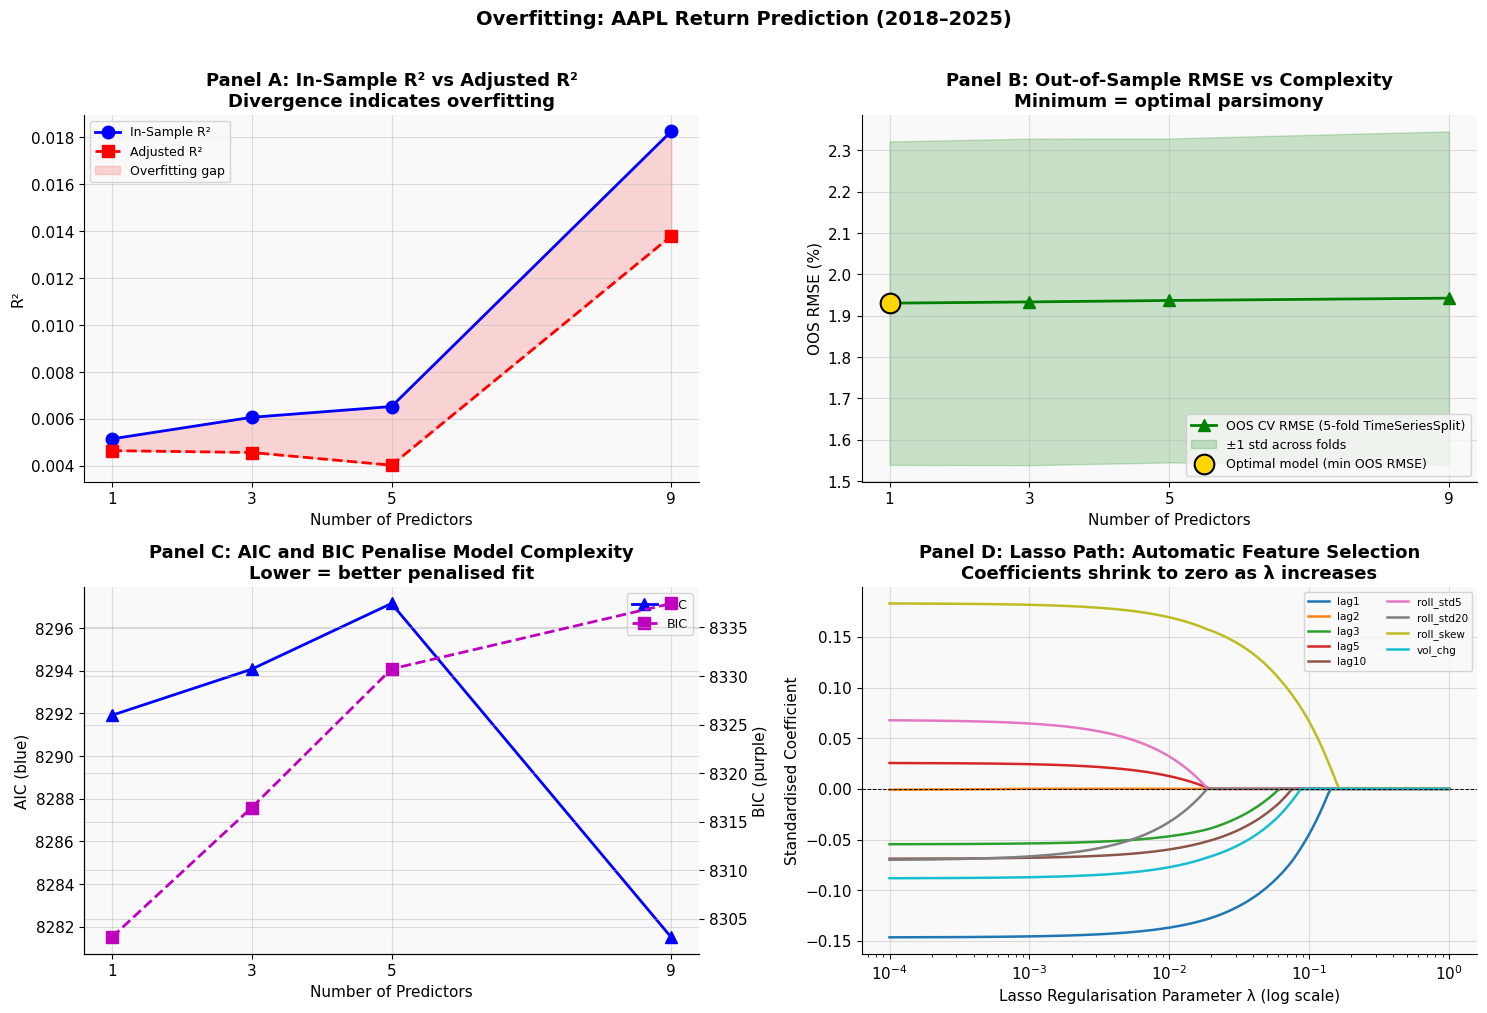

Figure 4 saved.


In [ ]:
#  OVERFITTING
#  Diagram

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

x_axis   = res_df['N Features']
x_labels = res_df['N Features']

#  Panel A: R² vs Adj.R²
axes[0,0].plot(x_axis, res_df['R²'],     'bo-', lw=2, ms=9, label='In-Sample R²')
axes[0,0].plot(x_axis, res_df['Adj. R²'],'rs--', lw=2, ms=9, label='Adjusted R²')
axes[0,0].fill_between(x_axis,
                        res_df['R²'], res_df['Adj. R²'],
                        alpha=0.15, color='red', label='Overfitting gap')
axes[0,0].set_xlabel('Number of Predictors')
axes[0,0].set_ylabel('R²')
axes[0,0].set_title('Panel A: In-Sample R² vs Adjusted R²\nDivergence indicates overfitting',
                     fontweight='bold')
axes[0,0].legend(fontsize=9)
axes[0,0].set_xticks(x_labels)

# ---- Panel B: OOS RMSE ----
axes[0,1].plot(x_axis, res_df['OOS RMSE'], 'g^-', lw=2, ms=9,
               label='OOS CV RMSE (5-fold TimeSeriesSplit)')
axes[0,1].fill_between(x_axis,
                        res_df['OOS RMSE'] - res_df['OOS RMSE σ'],
                        res_df['OOS RMSE'] + res_df['OOS RMSE σ'],
                        alpha=0.2, color='green', label='±1 std across folds')
min_idx = res_df['OOS RMSE'].idxmin()
axes[0,1].scatter(res_df.loc[min_idx,'N Features'],
                   res_df.loc[min_idx,'OOS RMSE'],
                   color='gold', s=200, zorder=6,
                   edgecolors='black', linewidths=1.5,
                   label='Optimal model (min OOS RMSE)')
axes[0,1].set_xlabel('Number of Predictors')
axes[0,1].set_ylabel('OOS RMSE (%)')
axes[0,1].set_title('Panel B: Out-of-Sample RMSE vs Complexity\nMinimum = optimal parsimony',
                     fontweight='bold')
axes[0,1].legend(fontsize=9)
axes[0,1].set_xticks(x_labels)

#Panel C: AIC and BIC
ax_c2 = axes[1,0].twinx()
axes[1,0].plot(x_axis, res_df['AIC'], 'b^-', lw=2, ms=8, label='AIC')
ax_c2.plot(x_axis, res_df['BIC'], 'ms--', lw=2, ms=8, label='BIC')
axes[1,0].set_xlabel('Number of Predictors')
axes[1,0].set_ylabel('AIC (blue)')
ax_c2.set_ylabel('BIC (purple)')
axes[1,0].set_title('Panel C: AIC and BIC Penalise Model Complexity\nLower = better penalised fit',
                     fontweight='bold')
l1, lab1 = axes[1,0].get_legend_handles_labels()
l2, lab2 = ax_c2.get_legend_handles_labels()
axes[1,0].legend(l1+l2, lab1+lab2, fontsize=9)
axes[1,0].set_xticks(x_labels)

#Panel D: Lasso Path
all_feats = ['lag1','lag2','lag3','lag5','lag10',
             'roll_std5','roll_std20','roll_skew','vol_chg']
X_all     = df_of[all_feats].values
scaler_of = StandardScaler()
X_all_sc  = scaler_of.fit_transform(X_all)
lasso_alphas = np.logspace(-4, 0, 200)
lasso_coefs  = np.array([
    Lasso(alpha=a, max_iter=10000).fit(X_all_sc, target).coef_
    for a in lasso_alphas
])
colors_lasso = plt.cm.tab10(np.linspace(0, 1, len(all_feats)))
for i, (feat, c) in enumerate(zip(all_feats, colors_lasso)):
    axes[1,1].plot(lasso_alphas, lasso_coefs[:, i], lw=1.8,
                   color=c, label=feat)
axes[1,1].set_xscale('log')
axes[1,1].axhline(0, color='black', lw=0.7, linestyle='--')
axes[1,1].set_xlabel('Lasso Regularisation Parameter λ (log scale)')
axes[1,1].set_ylabel('Standardised Coefficient')
axes[1,1].set_title('Panel D: Lasso Path: Automatic Feature Selection\nCoefficients shrink to zero as λ increases',
                     fontweight='bold')
axes[1,1].legend(fontsize=7.5, ncol=2)

plt.suptitle('Overfitting: AAPL Return Prediction (2018–2025)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_overfitting_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

In [ ]:
#  OVERFITTING
# Diagnosis |  Damage | Directions

print('DIAGNOSIS')
print('Indicators of overfitting in financial regression models:')
print('  1. R² rises with each added feature but Adj. R² stagnates or falls.')
print('  2. OOS RMSE worsens beyond the optimal number of predictors.')
print('  3. AIC/BIC increase after the optimal model, penalising excess complexity.')
print('  4. Lasso path: only lag1 survives meaningful regularisation — all others')
print('     shrink to zero, revealing they add no genuine predictive content.')
print()

print('DAMAGE')
print('Overfitting produces models that perform well in backtests but fail in')
print('production. On a derivatives desk this manifests as:')
print('  • Option prices that appear accurate in-sample but diverge from market')
print('    mid-prices out-of-sample, generating adverse selection by market-makers.')
print('  • Volatility forecasts that are too responsive to historical noise,')
print('    causing over-hedging in low-vol periods and under-hedging in crises.')
print('  • P&L attribution that assigns explanatory power to spurious factors,')
print('    misleading risk managers about the true sources of portfolio risk.')
print()

print('DIRECTIONS')
print('1. Model selection via BIC (penalises complexity more heavily than AIC).')
print('2. Lasso/Ridge regularisation: choose λ by time-series cross-validation.')
print('3. Walk-forward (expanding window) validation to simulate live conditions.')
print('4. Never use random train/test splits on financial data, use TimeSeriesSplit.')
print()

# Walk-forward validation on GARCH models of increasing lag order
print('Walk-Forward Validation: GARCH(p,q) Model Selection')
print(f'{"Model":<14} {"Log-Lik":>10} {"AIC":>10} {"BIC":>10}')
print('-' * 48)
for p, q in [(1,1),(1,2),(2,1),(2,2)]:
    try:
        gm   = arch_model(r_out, vol='Garch', p=p, q=q, dist='normal').fit(disp='off')
        print(f'GARCH({p},{q}){"":>6} {gm.loglikelihood:>10.2f} {gm.aic:>10.2f} {gm.bic:>10.2f}')
    except Exception:
        print(f'GARCH({p},{q}) — failed to converge')
print()
print('Best GARCH specification = lowest BIC.')
print('Adding lags beyond GARCH(1,1) typically overfits AAPL return volatility.')

DIAGNOSIS
Indicators of overfitting in financial regression models:
  1. R² rises with each added feature but Adj. R² stagnates or falls.
  2. OOS RMSE worsens beyond the optimal number of predictors.
  3. AIC/BIC increase after the optimal model, penalising excess complexity.
  4. Lasso path: only lag1 survives meaningful regularisation — all others
     shrink to zero, revealing they add no genuine predictive content.

DAMAGE
Overfitting produces models that perform well in backtests but fail in
production. On a derivatives desk this manifests as:
  • Option prices that appear accurate in-sample but diverge from market
    mid-prices out-of-sample, generating adverse selection by market-makers.
  • Volatility forecasts that are too responsive to historical noise,
    causing over-hedging in low-vol periods and under-hedging in crises.
  • P&L attribution that assigns explanatory power to spurious factors,
    misleading risk managers about the true sources of portfolio risk.

DIRECTI


## References

Engle, Robert F. "Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation." *Econometrica*, vol. 50, no. 4, 1982, pp. 987–1007.

Bollerslev, Tim. "Generalized Autoregressive Conditional Heteroskedasticity." *Journal of Econometrics*, vol. 31, no. 3, 1986, pp. 307–327.

Hoerl, Arthur E., and Robert W. Kennard. "Ridge Regression: Biased Estimation for Nonorthogonal Problems." *Technometrics*, vol. 12, no. 1, 1970, pp. 55–67.

Tibshirani, Robert. "Regression Shrinkage and Selection via the Lasso." *Journal of the Royal Statistical Society: Series B*, vol. 58, no. 1, 1996, pp. 267–288.

Cornish, E. A., and Ronald A. Fisher. "Moments and Cumulants in the Specification of Distributions." *Revue de l'Institut International de Statistique*, vol. 5, no. 4, 1938, pp. 307–320.

Jarque, Carlos M., and Anil K. Bera. "A Test for Normality of Observations and Regression Residuals." *International Statistical Review*, vol. 55, no. 2, 1987, pp. 163–172.

Yahoo Finance. Apple Inc. (AAPL) Historical Price Data. https://finance.yahoo.com/quote/AAPL/history/